In [ ]:
%%capture
%pip install langchain-openai==0.3.27
%pip install langgraph==0.6.6
%pip install pygraphviz==1.14

In [1]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")
OPENAI_ORG_ID = os.getenv("OPENAI_ORG_ID", "")

# Model Configuration
DEFAULT_MODEL = os.getenv("DEFAULT_MODEL", "gpt-3.5-turbo")
TEMPERATURE = float(os.getenv("TEMPERATURE", "0.7"))
MAX_TOKENS = int(os.getenv("MAX_TOKENS", "500"))
WATSON_URL = os.getenv("IBM_URL_END_POINT")
PROJECT_ID = os.getenv("IBM_PROJECT_ID")
IBM_API_KEY = os.getenv("IBM_API_KEY")
TAVILY_KEY = os.getenv("TAVILY_API_KEY")

In [2]:
from langgraph.graph import StateGraph, END,START
from typing import TypedDict
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph

/home/samuel/Desktop/ai_applications_coursera/venv/lib/python3.12/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [3]:
def print_workflow_info(workflow, app=None):
    """Prints comprehensive information about a LangGraph workflow."""
    print("WORKFLOW INFORMATION")
    print("====================")
    print(f"Nodes: {workflow.nodes}")
    print(f"Edges: {workflow.edges}")

    
    # Use getter method for finish points if available
    try:
        finish_points = workflow.finish_points
        print(f"Finish points: {finish_points}")
    except:
        try:
            # Alternative approaches
            print(f"Finish point: {workflow._finish_point}")
        except:
            print("Finish points attribute not directly accessible")
    
    if app:
        print("\nWorkflow Visualization:")
        from IPython.display import display
        display(app.get_graph().draw_png())

In [4]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [5]:
class ChainState(TypedDict):
    job_description: str
    resume_summary: str
    cover_letter: str

In [6]:
def generate_resume_summary(state: ChainState) -> ChainState:
    prompt = f"""
You're a resume assistant. Read the following job description and summarize the key qualifications and experience the ideal candidate should have, phrased as if from the perspective of a strong applicant's resume summary.

Job Description:
{state['job_description']}
"""

    response = llm.invoke(prompt)

    return {**state, "resume_summary": response.content}

In [7]:
def generate_cover_letter(state: ChainState) -> ChainState:
    prompt = f"""
You're a cover letter writing assistant. Using the resume summary below, write a professional and personalized cover letter for the following job.

Resume Summary:
{state['resume_summary']}

Job Description:
{state['job_description']}
"""

    response = llm.invoke(prompt)

    return {**state, "cover_letter": response.content}

In [8]:
workflow = StateGraph(ChainState)
workflow

In [9]:
workflow.add_node("generate_resume_summary", generate_resume_summary)
workflow.add_node("generate_cover_letter", generate_cover_letter)

In [10]:
workflow.set_entry_point("generate_resume_summary")
workflow.add_edge("generate_resume_summary", "generate_cover_letter")
workflow.set_finish_point("generate_cover_letter")
print_workflow_info(workflow)

WORKFLOW INFORMATION
Nodes: {'generate_resume_summary': StateNodeSpec(runnable=generate_resume_summary(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.ChainState'>, retry_policy=None, cache_policy=None, ends=(), defer=False), 'generate_cover_letter': StateNodeSpec(runnable=generate_cover_letter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.ChainState'>, retry_policy=None, cache_policy=None, ends=(), defer=False)}
Edges: {('generate_cover_letter', '__end__'), ('__start__', 'generate_resume_summary'), ('generate_resume_summary', 'generate_cover_letter')}
Finish points attribute not directly accessible


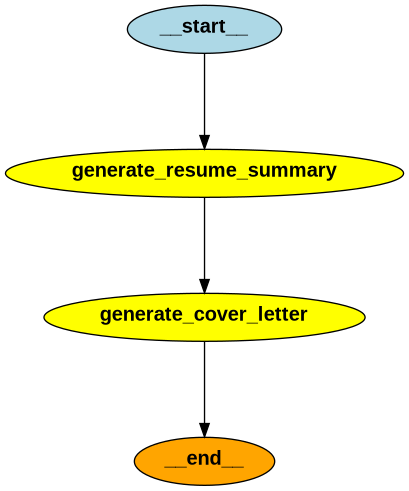

In [11]:
app = workflow.compile()
from IPython.display import Image, display

# Generate a visualization of the workflow graph
display(Image(app.get_graph().draw_png()))

In [12]:
input_state = {
        "job_description": "We are looking for a data scientist with experience in machine learning, NLP, and Python. Prior work with large datasets and experience deploying models into production is required."
}

result = app.invoke(input_state)


In [13]:
result['resume_summary']

'Resume Summary:\n\nDynamic data scientist with robust experience in machine learning and natural language processing (NLP), proficient in Python programming. Demonstrated expertise in handling large datasets and successfully deploying machine learning models into production environments. Adept at transforming complex data into actionable insights, driving innovation and efficiency through advanced analytical techniques. Proven ability to deliver impactful solutions that enhance decision-making processes.'

In [14]:
class RouterState(TypedDict):
    user_input: str
    task_type: str
    output: str

In [15]:
class Router(BaseModel):
    role: str = Field(..., description="Decide whether the user wants to summarize a passage  ouput 'summarize'  or translate text into French oupput translate.")
llm_router=llm.bind_tools([Router])

In [16]:
response=llm_router.invoke("summarize this I love the sun its so warm")

In [17]:
def router_node(state: RouterState) -> RouterState:
    routing_prompt = f"""
    You are an AI task classifier.
    
    Decide whether the user wants to:
    - "summarize" a passage
    - or "translate" text into French
    
    Respond with just one word: 'summarize' or 'translate'.
    
    User Input: "{state['user_input']}"
    """

    response = llm_router.invoke(routing_prompt)

    return {**state, "task_type": response.tool_calls[0]['args']['role']} # This becomes the next node's name!

In [18]:
def router(state: RouterState) -> str:
    return state['task_type']

In [19]:
def summarize_node(state: RouterState) -> RouterState:
    prompt = f"Please summarize the following passage:\n\n{state['user_input']}"
    response = llm.invoke(prompt)
    
    return {**state, "task_type": "summarize", "output": response.content}

In [20]:
def translate_node(state: RouterState) -> RouterState:
    prompt = f"Translate the following text to French:\n\n{state['user_input']}"
    response = llm.invoke(prompt)

    return {**state, "task_type": "translate", "output": response.content}

In [21]:
workflow = StateGraph(RouterState)


In [22]:
workflow.add_node("router", router_node)
workflow.add_node("summarize", summarize_node)
workflow.add_node("translate", translate_node)

In [23]:
workflow.set_entry_point("router")

In [24]:
workflow.add_conditional_edges("router", router, {
    "summarize": "summarize",
    "translate": "translate"
})

In [25]:
workflow.set_finish_point("summarize")
workflow.set_finish_point("translate")

In [26]:
app = workflow.compile()


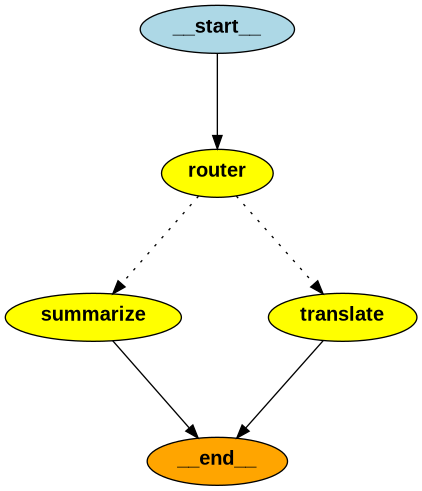

In [27]:
from IPython.display import Image, display

# Generate a visualization of the workflow graph
display(Image(app.get_graph().draw_png()))

In [28]:
input_text = {
        "user_input": "Can you translate this sentence: I love programming?"
    }

result = app.invoke(input_text)

In [29]:
print(result[ 'output'])
print(result['task_type'])

Sure! The translation of "I love programming" in French is "J'aime la programmation."
translate


In [30]:
input_text = {
        "user_input": "Can you summarize this sentence: I love programming so much it is the best thing ever. All I want to do is programming?"
    }

result = app.invoke(input_text)

In [31]:
print(result[ 'output'])
print(result['task_type'])

The sentence expresses a deep passion for programming, stating that it is the speaker's favorite activity and their primary desire.
summarize


In [32]:
class State(TypedDict):
    text: str
    french: str
    spanish: str
    japanese: str
    combined_output: str

In [33]:
def translate_french(state: State) -> dict:
    response = llm.invoke(f"Translate the following text to French:\n\n{state['text']}")
    return {"french": response.content.strip()}

In [34]:
def translate_japanese(state: State) -> dict:
    response = llm.invoke(f"Translate the following text to Japanese:\n\n{state['text']}")
    return {"japanese": response.content.strip()}

In [35]:
def translate_spanish(state: State) -> dict:
    response = llm.invoke(f"Translate the following text to Spanish:\n\n{state['text']}")
    return {"spanish": response.content.strip()}

In [36]:
def aggregator(state: State) -> dict:
    combined = f"Original Text: {state['text']}\n\n"
    combined += f"French: {state['french']}\n\n"
    combined += f"Spanish: {state['spanish']}\n\n"
    combined += f"Japanese: {state['japanese']}\n"
    return {"combined_output": combined}

In [37]:
graph = StateGraph(State)

In [38]:
graph.add_node("translate_french", translate_french)
graph.add_node("translate_spanish", translate_spanish)
graph.add_node("translate_japanese", translate_japanese)
graph.add_node("aggregator", aggregator)

In [39]:
# Connect parallel nodes from START
graph.add_edge(START, "translate_french")
graph.add_edge(START, "translate_spanish")
graph.add_edge(START, "translate_japanese")

In [40]:
# Connect all translation nodes to the aggregator
graph.add_edge("translate_french", "aggregator")
graph.add_edge("translate_spanish", "aggregator")
graph.add_edge("translate_japanese", "aggregator")

In [41]:
# Final node
graph.add_edge("aggregator", END)

In [42]:
# Compile the graph
app = graph.compile()

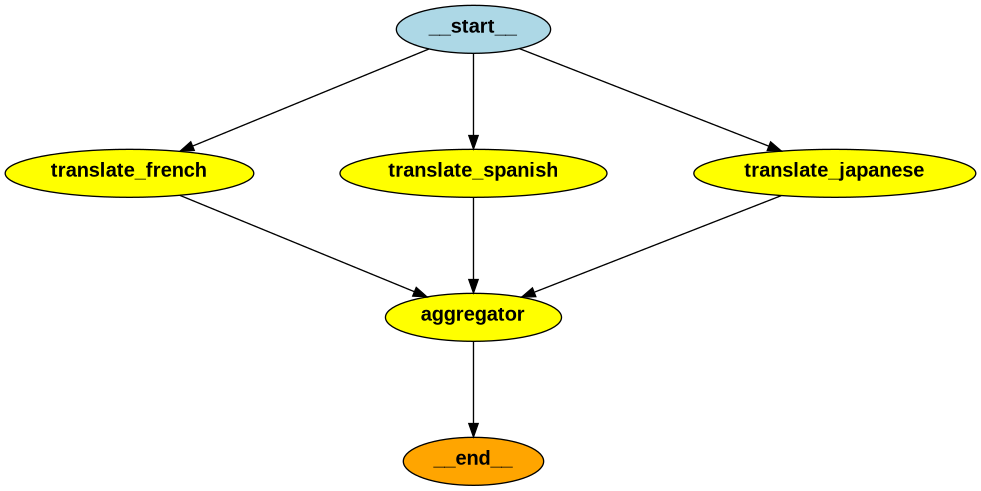

In [43]:
from IPython.display import Image, display

# Generate a visualization of the workflow graph
display(Image(app.get_graph().draw_png()))

In [44]:
input_text = {
        "text": "Good morning! I hope you have a wonderful day."
}

result = app.invoke(input_text)

In [45]:
result

{'text': 'Good morning! I hope you have a wonderful day.',
 'french': "Bonjour ! J'espère que vous passerez une merveilleuse journée.",
 'spanish': '¡Buenos días! Espero que tengas un día maravilloso.',
 'japanese': 'おはようございます！素晴らしい一日を過ごせますように。',
 'combined_output': "Original Text: Good morning! I hope you have a wonderful day.\n\nFrench: Bonjour ! J'espère que vous passerez une merveilleuse journée.\n\nSpanish: ¡Buenos días! Espero que tengas un día maravilloso.\n\nJapanese: おはようございます！素晴らしい一日を過ごせますように。\n"}